# End to end read test for icechunk data on CEDA

I produced example icechunk stores in `build_static_examples.ipynb` here, and Daniel Westwood exposed them via HTTP on JASMIN. 

> <https://gws-access.jasmin.ac.uk/public/eds_ai/test-icechunk>

This notebook tests the full read path. 

No S3 API, no object-store gateway — just static files behind a web server. This
notebook shows that a client can nevertheless open it as a virtual Zarr store and
pull data out of it, with the chunks still being served from the original NetCDF
files on the CEDA data node.

<div class="alert alert-warning"><b>Warning:</b> The read from HTTP requires icechunk v2, which reads the v1 repository just fine. </div> 


In [1]:
import icechunk

print(f"icechunk {icechunk.__version__}")

icechunk 2.1.1


## Opening the store

In [3]:
from cmip7_virtualization.storage import open_http_repository

JASMIN_STORE = "https://gws-access.jasmin.ac.uk/public/eds_ai/test-icechunk"
CEDA_DAP = "https://dap.ceda.ac.uk/"

repo = open_http_repository(JASMIN_STORE, virtual_prefixes=[CEDA_DAP])

for snapshot in repo.ancestry(branch="main"):
    print(f"{snapshot.id}  {snapshot.message}")

XT6MHXB5X00G7TNYWK0G  cmip
1CECHNKREP0F1RSTCMT0  Repository initialized


The commit history survived the transfer intact.
Note the store is **read-only**: HTTP storage
cannot commit, so `repo.writable_session(...)` will raise.

## As an xarray Dataset

Everything below this point is ordinary Zarr V3 access.

In [4]:
import xarray as xr

session = repo.readonly_session("main")
ds = xr.open_zarr(session.store, consolidated=False, zarr_format=3)
ds

/Users/juliusbusecke/Code/cmip7-virtualization/.worktrees/icechunk-2-live-read/.venv/lib/python3.12/site-packages/zarr/codecs/numcodecs/_codecs.py:139: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


<xarray.Dataset> Size: 982MB
Dimensions:    (time: 1110, bnds: 2, lat: 144, lon: 192, plev: 8)
Coordinates:
  * time       (time) object 9kB 1991-06-01 12:00:00 ... 1994-06-30 12:00:00
  * lat        (lat) float64 1kB -89.38 -88.12 -86.88 ... 86.88 88.12 89.38
  * lon        (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
  * plev       (plev) float64 64B 1e+05 8.5e+04 7e+04 ... 1e+04 5e+03 1e+03
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 18kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    lat_bnds   (lat, bnds) float64 2kB dask.array<chunksize=(144, 2), meta=np.ndarray>
    lon_bnds   (lon, bnds) float64 3kB dask.array<chunksize=(192, 2), meta=np.ndarray>
    zg         (time, plev, lat, lon) float32 982MB dask.array<chunksize=(1, 8, 144, 192), meta=np.ndarray>
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            VolMIP
    branch_method:          standard
    branch_time_in_child:   50910.0
    branch_time_in_parent:  432870.0
    creation_date:          2023-08-04T00:36:24Z
    ...                     ...
    tracking_id:            hdl:21.14100/731ffca5-707a-4378-a65e-bf801b7787c4
    variable_id:            zg
    variable_name:          zg
    variant_label:          r9i1p1f2
    license:                CMIP6 model data produced by the Natural Environm...
    cmor_version:           3.7.1

## Loading virtual chunk data

In [11]:
da = ds.zg.isel(plev=0, time=slice(0,100)).mean('time').load()

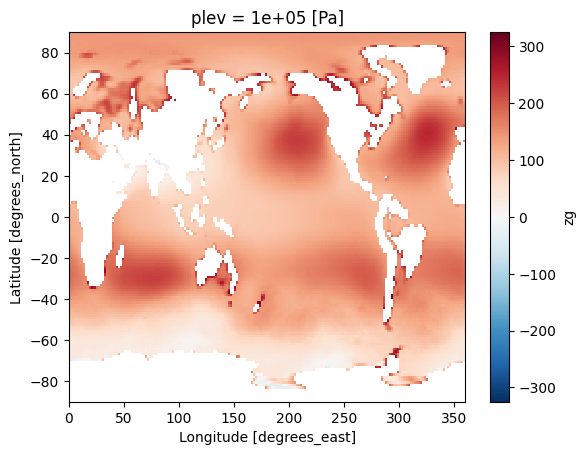

In [12]:
da.plot()

In [5]:
import numpy as np

levels = ds.zg.isel(time=0).load()
pressures = ds.plev.values / 100  # Pa -> hPa
mean_height = [float(levels.isel(plev=i).mean()) for i in range(ds.sizes["plev"])]
finite_frac = [float(np.isfinite(levels.isel(plev=i)).mean()) for i in range(ds.sizes["plev"])]

for p, h, f in zip(pressures, mean_height, finite_frac):
    print(f"{p:7.0f} hPa   mean height {h:8.1f} m   defined over {f:5.1%} of the globe")

   1000 hPa   mean height    143.1 m   defined over 61.2% of the globe
    850 hPa   mean height   1439.4 m   defined over 89.9% of the globe
    700 hPa   mean height   2982.6 m   defined over 94.7% of the globe
    500 hPa   mean height   5522.2 m   defined over 100.0% of the globe
    250 hPa   mean height  10288.1 m   defined over 100.0% of the globe
    100 hPa   mean height  16023.6 m   defined over 100.0% of the globe
     50 hPa   mean height  20324.0 m   defined over 100.0% of the globe
     10 hPa   mean height  30672.7 m   defined over 100.0% of the globe


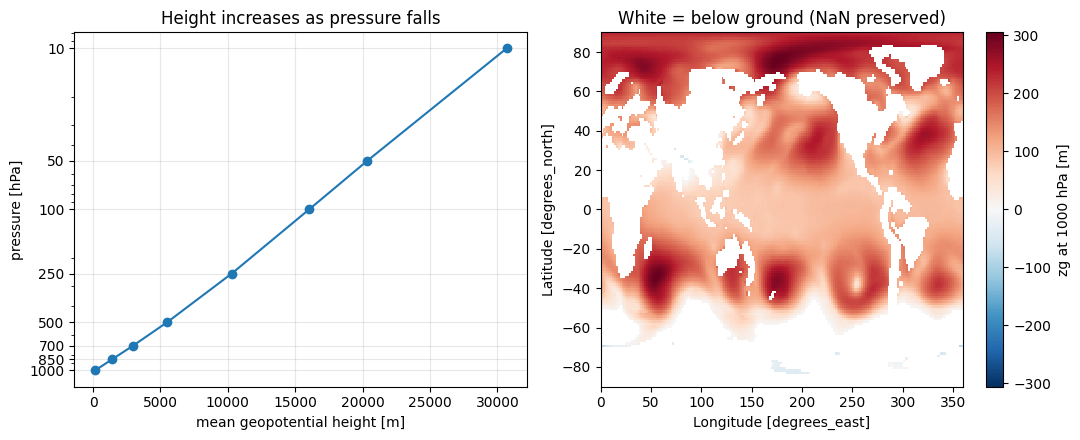

In [6]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

ax1.plot(mean_height, pressures, "o-")
ax1.set(xlabel="mean geopotential height [m]", ylabel="pressure [hPa]", yscale="log")
ax1.invert_yaxis()
ax1.set_yticks(pressures)
ax1.set_yticklabels([f"{p:.0f}" for p in pressures])
ax1.set_title("Height increases as pressure falls")
ax1.grid(alpha=0.3)

levels.isel(plev=0).plot(ax=ax2, cbar_kwargs={"label": "zg at 1000 hPa [m]"})
ax2.set_title("White = below ground (NaN preserved)")

fig.tight_layout()

## What this establishes

- Users can actually read virtual icechunk stores, located on HTTP servers,  that point to a different HTTP source for data

The checks above run in CI as `tests/test_live_icechunk.py`, so a host outage, a
rebuilt store, or an icechunk regression shows up as a test failure:

```bash
uv run pytest tests/test_live_icechunk.py     # or -m "not live" to skip network tests
```